# Barcode sequence correction

We have aligned all ORFs with high mapping efficiency to known cDNA sequences.

We also know that there appear to be many unique barcodes per cDNA, which may be explained by sequencing errors in the barcode part of the reads. 

Let's check this for one example cDNA sequence (the example was chosen because it did have too many unique barcodes):

In [18]:
%%bash

DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

# Fetch all alignments for the transcript ENST00000398232.7
# Print the last field (barcode sequence)
samtools view $DATA_DIR/orfs_aligned.bam | grep "ENST00000398232.7"  | awk -F':' '{print $NF}' 

TTTAAGTAATAGTGGAATGGGG
TTTAAGTAATAGTGGAATAAGGGG
AGTGTCCTTCCGAATCAGGTCGCC
TTTAAGTAATAGTGGAATAAGGGG
CAGAGGTGCTATTTAAAGTCTATTA
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAAAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG


## Testing of barcode sequences for one example cDNA

There appear to be 7 unique barcode sequences, but when we take the potential errors into account, there may be only 5 unique barcodes.

In our final annotation we do not want to artificially inflate the number of unique barcodes per cDNA, so we will need to correct for these potential sequencing errors.

Strategy for correction:
* **Length filtering**: The barcodes should be either 24 bp or 30 bp long, so barcodes can be length filtered within a small window.
* **Length-specific clusters**: Since a 24 bp barcode is unlikely to be a "broken" version of a 30 bp barcode, we can process these two length-classes separately to avoid over-correction.
* **Frequency-Based "Centroids"**: Identify the most frequent barcodes of exactly 24 or 30 bp and use them as the "truth" to which other sequences are mapped.
* **Frequency Gate**: A sequence can only be corrected to a parent if that parent is significantly more abundant (e.g., at least 5x or 10x more reads).
* **Distance vs. Frequency**: We can allow a larger distance (like 4) for high-frequency parents, but keep it strict (1 or 2) for lower-frequency parents.


First generate a test BAM file with just the reads of the cDNA used above:

In [4]:
%%bash

DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

samtools view -h $DATA_DIR/orfs_aligned.bam | \
	grep "ENST00000398232.7" | \
	samtools view -b -o $DATA_DIR/test.bam -

Now run this barcode correction script on this test BAM file:

```python
import argparse
import pysam
from collections import Counter
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm

# Create command line parser for better usability
parser = argparse.ArgumentParser(
    description="Correct barcode sequences in a BAM file using Levenshtein distance."
)
parser.add_argument("-i", "--input", required=True, help="Input BAM file")
parser.add_argument("-o", "--output", required=True, help="Output BAM file")
parser.add_argument(
    "--target-lengths",
    nargs="+",
    type=int,
    default=[24, 30],
    help="Target barcode lengths to consider as centroids (default: 24 30)",
)
parser.add_argument(
    "--window",
    type=int,
    default=2,
    help="Maximum length difference to consider for correction (default: 2)",
)
parser.add_argument(
    "--max-edit-dist",
    type=int,
    default=2,
    help="Maximum Levenshtein distance for correction (default: 2)",
)
parser.add_argument(
    "--ratio-threshold",
    type=int,
    default=5,
    help="Minimum frequency ratio for correction (default: 5)",
)


# Get parsed arguments
args = parser.parse_args()
input_bam = args.input
output_bam = args.output

TARGET_LENGTHS = set(args.target_lengths)
WINDOW = args.window
MAX_EDIT_DIST = args.max_edit_dist
RATIO_THRESHOLD = 5  # Minimum frequency ratio for correction


def process_group(reads, writer):
    raw_bcs = [r.get_tag("BC") for r in reads if r.has_tag("BC")]
    if not raw_bcs:
        for r in reads: writer.write(r)
        return

    counts = Counter(raw_bcs)
    unique_bcs = sorted(counts.keys(), key=lambda x: counts[x], reverse=True)
    
    # Only sequences of target length can be parents
    centroids = [b for b in unique_bcs if len(b) in TARGET_LENGTHS]
    
    correction_map = {}
    for seq in unique_bcs:
        if seq in centroids:
            correction_map[seq] = seq
            # We don't skip 'continue' here because a centroid could technically 
            # be an error of a much larger centroid (e.g., if one 24bp is 100x 
            # more frequent than another 24bp). If you want centroids to stay 
            # unique, keep 'continue'.
            continue
        
        seq_count = counts[seq]
        candidates = []

        for c in centroids:
            # Abundance Check
            if counts[c] >= (seq_count * RATIO_THRESHOLD):
                # Length Window Check
                if abs(len(seq) - len(c)) <= WINDOW:
                    # Edit Distance Check
                    dist = Levenshtein.distance(seq, c, score_cutoff=MAX_EDIT_DIST)
                    if dist <= MAX_EDIT_DIST:
                        candidates.append((dist, counts[c], c))

        if candidates:
            # Sort by smallest distance first, then highest count
            candidates.sort(key=lambda x: (x[0], -x[1]))
            correction_map[seq] = candidates[0][2]
        else:
            correction_map[seq] = seq

    for read in reads:
        if read.has_tag("BC"):
            old_bc = read.get_tag("BC")
            read.set_tag("BC", correction_map.get(old_bc, old_bc))
        writer.write(read)


def main():
    # Suppress pysam warnings for missing indices if necessary
    pysam.set_verbosity(0)

    with pysam.AlignmentFile(input_bam, "rb") as reader:
        # Get total mapped reads for the progress bar
        # BAM file is indexed prior to this step
        total_reads = reader.mapped

        with pysam.AlignmentFile(output_bam, "wb", template=reader) as writer:
            pbar = tqdm(total=total_reads, desc="Correcting Barcodes", unit="reads")

            current_rname = None
            reads_in_group = []

            for read in reader:
                rname = read.reference_name

                if rname != current_rname:
                    if reads_in_group:
                        process_group(reads_in_group, writer)
                        pbar.update(len(reads_in_group))

                    current_rname = rname
                    reads_in_group = [read]
                else:
                    reads_in_group.append(read)

            # Final group
            if reads_in_group:
                process_group(reads_in_group, writer)
                pbar.update(len(reads_in_group))

            pbar.close()


if __name__ == "__main__":
    main()
```

In [20]:
%%bash

DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"
# Standard values:
# - Window: 2
# - Max edit distance: 2
python 06_levenshtein.py -i $DATA_DIR/test.bam -o $DATA_DIR/test_bc_corrected.bam
samtools view $DATA_DIR/test_bc_corrected.bam | awk -F':' '{print $NF}'

echo "Unique barcodes after correction:"
samtools view $DATA_DIR/test_bc_corrected.bam | awk -F':' '{print $NF}' | sort | uniq | wc -l

Correcting Barcodes: 100%|██████████| 16/16 [00:00<00:00, 38435.78reads/s]


TTTAAGTAATAGTGGAATAAGGGG
TTTAAGTAATAGTGGAATAAGGGG
AGTGTCCTTCCGAATCAGGTCGCC
TTTAAGTAATAGTGGAATAAGGGG
AGAGGTGCTATTTAAAGTCTATTA
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAAAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
Unique barcodes after correction:
5


Easier to see corrections in a table format:

| Original sequence            | Corrected sequence           |
|------------------------------|------------------------------|
| TTTAAGTAATAGTGGAATGGGG       | TTTAAGTAATAGTGGAATAAGGGG     |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG     |
| AGTGTCCTTCCGAATCAGGTCGCC     | AGTGTCCTTCCGAATCAGGTCGCC     |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG     |
| CAGAGGTGCTATTTAAAGTCTATTA    | AGAGGTGCTATTTAAAGTCTATTA     |
| TACTAGTGAGTTAGGGGCTATGGT     | TACTAGTGAGTTAGGGGCTATGGT     |
| AGAGGTGCTATTTAAAAAAAGTCTATTA | AGAGGTGCTATTTAAAAAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA     |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA     |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG     |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA     |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG     |
| TACTAGTGAGTTAGGGGCTATGGT     | TACTAGTGAGTTAGGGGCTATGGT     |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA     |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA     |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG     |

The AGAGGTGCTATTTAAAAAAAGTCTATTA barcode realy looks like AGAGGTGCTATTTAAAGTCTATTA, but with a AAAA insertion.

Running again with `window=4` and `max-edit-dist=4` should correct this one:

In [22]:
%%bash

DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/test.bam -o $DATA_DIR/test_bc_corrected_window4_dist4.bam --window 4 --max-edit-dist 4

samtools view $DATA_DIR/test_bc_corrected_window4_dist4.bam | awk -F':' '{print $NF}'
echo "Unique barcodes after correction with window=4 and max-edit-dist=4:"
samtools view $DATA_DIR/test_bc_corrected_window4_dist4.bam | awk -F':' '{print $NF}' | sort | uniq | wc -l



Correcting Barcodes: 100%|██████████| 16/16 [00:00<00:00, 33337.74reads/s]


TTTAAGTAATAGTGGAATAAGGGG
TTTAAGTAATAGTGGAATAAGGGG
AGTGTCCTTCCGAATCAGGTCGCC
TTTAAGTAATAGTGGAATAAGGGG
AGAGGTGCTATTTAAAGTCTATTA
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
TACTAGTGAGTTAGGGGCTATGGT
AGAGGTGCTATTTAAAGTCTATTA
AGAGGTGCTATTTAAAGTCTATTA
TTTAAGTAATAGTGGAATAAGGGG
Unique barcodes after correction with window=4 and max-edit-dist=4:
4


| Original sequence            | Corrected sequence       |
|------------------------------|--------------------------|
| AGAGGTGCTATTTAAAAAAAGTCTATTA | AGAGGTGCTATTTAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA |
| AGAGGTGCTATTTAAAGTCTATTA     | AGAGGTGCTATTTAAAGTCTATTA |
| AGTGTCCTTCCGAATCAGGTCGCC     | AGTGTCCTTCCGAATCAGGTCGCC |
| CAGAGGTGCTATTTAAAGTCTATTA    | AGAGGTGCTATTTAAAGTCTATTA |
| TACTAGTGAGTTAGGGGCTATGGT     | TACTAGTGAGTTAGGGGCTATGGT |
| TACTAGTGAGTTAGGGGCTATGGT     | TACTAGTGAGTTAGGGGCTATGGT |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG |
| TTTAAGTAATAGTGGAATAAGGGG     | TTTAAGTAATAGTGGAATAAGGGG |
| TTTAAGTAATAGTGGAATGGGG       | TTTAAGTAATAGTGGAATAAGGGG |

(Table has been sorted in LibreOffice Calc)

## Testing on bigger test data set

We have tested the script on a single cDNA test data set, but now try to optimise the parameters on a bigger test data set with more cDNAs and more barcodes.

Subset for 100K reads.

Then run script with different values for `window`, `max-edit-dist`, and `ratio-threshold` to find the optimal parameters that balance correction with over-correction.

Generate a table like this:

| Window | Dist | Ratio | % Reads Corrected | Unique BCs Remaining |
|--------|------|-------|-------------------|----------------------|
| 2      | 2    | 5.0   | 75%               | 450                  |
| 4      | 4    | 5.0   | 92%               | 310                  |
| 4      | 4    | 2.0   | 96%               | 240                  |

The winner is the row where % Reads Corrected is high, but Unique BCs Remaining matches the number of expected unique barcodes (which may be unknown!).

In [26]:
%%bash 

# Create bigger test data set with 100K reads
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"
samtools view -b -s 42.01 -o $DATA_DIR/test_100K.bam $DATA_DIR/orfs_aligned.bam

samtools index $DATA_DIR/test_100K.bam

Updated the script to include counting of

* Total Barcodes: Every barcode found in the BAM.

* Total Corrected: Every instance where a barcode was changed to a centroid.

* Unique Before: Total unique barcode strings encountered.

* Unique After: Total unique barcode strings remaining in the output.

```python
import argparse
import pysam
from collections import Counter
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm

# Create command line parser
parser = argparse.ArgumentParser(
    description="Correct barcode sequences in a BAM file using Levenshtein distance."
)
parser.add_argument("-i", "--input", required=True, help="Input BAM file")
parser.add_argument("-o", "--output", required=True, help="Output BAM file")
parser.add_argument(
    "--target-lengths",
    nargs="+",
    type=int,
    default=[24, 30],
    help="Target barcode lengths to consider as centroids (default: 24 30)",
)
parser.add_argument(
    "--window",
    type=int,
    default=2,
    help="Maximum length difference to consider for correction (default: 2)",
)
parser.add_argument(
    "--max-edit-dist",
    type=int,
    default=2,
    help="Maximum Levenshtein distance for correction (default: 2)",
)
parser.add_argument(
    "--ratio-threshold",
    type=int,
    default=5,
    help="Minimum frequency ratio for correction (default: 5)",
)

args = parser.parse_args()

# Global metrics
STATS = {
    "total_reads_with_bc": 0,
    "total_corrected_reads": 0,
    "unique_bcs_before": set(),
    "unique_bcs_after": set(),
}


def process_group(reads, writer):
    # Filter reads that actually have a BC tag
    reads_with_bc = [r for r in reads if r.has_tag("BC")]

    # Write reads without BC immediately and move on
    for r in reads:
        if not r.has_tag("BC"):
            writer.write(r)

    if not reads_with_bc:
        return

    raw_bcs = [r.get_tag("BC") for r in reads_with_bc]
    counts = Counter(raw_bcs)
    unique_bcs = sorted(counts.keys(), key=lambda x: counts[x], reverse=True)

    # Update "Before" stats
    STATS["total_reads_with_bc"] += len(raw_bcs)
    STATS["unique_bcs_before"].update(unique_bcs)

    centroids = [b for b in unique_bcs if len(b) in args.target_lengths]
    correction_map = {}

    for seq in unique_bcs:
        if seq in centroids:
            correction_map[seq] = seq
            continue

        seq_count = counts[seq]
        candidates = []

        for c in centroids:
            if counts[c] >= (seq_count * args.ratio_threshold):
                if abs(len(seq) - len(c)) <= args.window:
                    dist = Levenshtein.distance(seq, c, score_cutoff=args.max_edit_dist)
                    if dist <= args.max_edit_dist:
                        candidates.append((dist, counts[c], c))

        if candidates:
            candidates.sort(key=lambda x: (x[0], -x[1]))
            correction_map[seq] = candidates[0][2]
        else:
            correction_map[seq] = seq

    # Write updated reads and update "After" stats
    for read in reads_with_bc:
        old_bc = read.get_tag("BC")
        new_bc = correction_map.get(old_bc, old_bc)

        if old_bc != new_bc:
            STATS["total_corrected_reads"] += 1
            read.set_tag("BC", new_bc)

        STATS["unique_bcs_after"].add(new_bc)
        writer.write(read)


def main():
    pysam.set_verbosity(0)

    with pysam.AlignmentFile(args.input, "rb") as reader:
        total_reads = reader.mapped
        with pysam.AlignmentFile(args.output, "wb", template=reader) as writer:
            pbar = tqdm(total=total_reads, desc="Correcting Barcodes", unit="reads")

            current_rname = None
            reads_in_group = []

            for read in reader:
                rname = read.reference_name
                if rname != current_rname:
                    if reads_in_group:
                        process_group(reads_in_group, writer)
                        pbar.update(len(reads_in_group))
                    current_rname = rname
                    reads_in_group = [read]
                else:
                    reads_in_group.append(read)

            if reads_in_group:
                process_group(reads_in_group, writer)
                pbar.update(len(reads_in_group))
            pbar.close()

    # Final Summary Report
    print("\n" + "="*40)
    print("BARCODE CORRECTION SUMMARY")
    print("="*40)
    print(f"Input file:      {args.input}")
    print(f"Target lengths:  {args.target_lengths}")
    print(f"Window size:     {args.window}")
    print(f"Max Edit Dist:   {args.max_edit_dist}")
    print(f"Ratio Threshold: {args.ratio_threshold}")
    print("-" * 40)
    print(f"Total reads processed (with BC):  {STATS['total_reads_with_bc']:,}")
    print(f"Total reads corrected:            {STATS['total_corrected_reads']:,}")
    
    if STATS['total_reads_with_bc'] > 0:
        corr_pct = (STATS['total_corrected_reads'] / STATS['total_reads_with_bc']) * 100
        print(f"Correction rate:                  {corr_pct:.2f}%")
        
    print("-" * 40)
    print(f"Unique barcodes (Before):         {len(STATS['unique_bcs_before']):,}")
    print(f"Unique barcodes (After):          {len(STATS['unique_bcs_after']):,}")
    
    unique_diff = len(STATS['unique_bcs_before']) - len(STATS['unique_bcs_after'])
    print(f"Unique barcodes collapsed:        {unique_diff:,}")
    print("="*40 + "\n")


if __name__ == "__main__":
    main()
```


In [29]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/test_100K.bam -o $DATA_DIR/test_100K_bc_corrected_window2_dist2_ratio5.bam --window 2 --max-edit-dist 2 --ratio-threshold 5

python 06_levenshtein.py -i $DATA_DIR/test_100K.bam -o $DATA_DIR/test_100K_bc_corrected_window4_dist4_ratio5.bam --window 4 --max-edit-dist 4 --ratio-threshold 5

python 06_levenshtein.py -i $DATA_DIR/test_100K.bam -o $DATA_DIR/test_100K_bc_corrected_window4_dist4_ratio2.bam --window 4 --max-edit-dist 4 --ratio-threshold 2

Correcting Barcodes: 116937reads [00:05, 22063.48reads/s]                         /s]/s]/s]/s]/s]



BARCODE CORRECTION SUMMARY
Input file:      /media/niek/4TB_SSD2/analyses/GPS_ONT/test_100K.bam
Target lengths:  [24, 30]
Window size:     2
Max Edit Dist:   2
Ratio Threshold: 5
----------------------------------------
Total reads processed (with BC):  116,937
Total reads corrected:            16
Correction rate:                  0.01%
----------------------------------------
Unique barcodes (Before):         78,593
Unique barcodes (After):          78,577
Unique barcodes collapsed:        16



Correcting Barcodes: 116937reads [00:05, 21585.37reads/s]                         /s]/s]/s]/s]/s]



BARCODE CORRECTION SUMMARY
Input file:      /media/niek/4TB_SSD2/analyses/GPS_ONT/test_100K.bam
Target lengths:  [24, 30]
Window size:     4
Max Edit Dist:   4
Ratio Threshold: 5
----------------------------------------
Total reads processed (with BC):  116,937
Total reads corrected:            19
Correction rate:                  0.02%
----------------------------------------
Unique barcodes (Before):         78,593
Unique barcodes (After):          78,574
Unique barcodes collapsed:        19



Correcting Barcodes: 116937reads [00:05, 21584.77reads/s]                         /s]/s]/s]/s]/s]



BARCODE CORRECTION SUMMARY
Input file:      /media/niek/4TB_SSD2/analyses/GPS_ONT/test_100K.bam
Target lengths:  [24, 30]
Window size:     4
Max Edit Dist:   4
Ratio Threshold: 2
----------------------------------------
Total reads processed (with BC):  116,937
Total reads corrected:            695
Correction rate:                  0.59%
----------------------------------------
Unique barcodes (Before):         78,593
Unique barcodes (After):          77,914
Unique barcodes collapsed:        679



Relatively low correction counts.

It could be the data is not dense enough to allow for more corrections, or the parameters are too strict.

Try on full data set.

In [ ]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/orfs_aligned.bam -o $DATA_DIR/orfs_bc_corrected_window4_dist4_ratio5.bam --window 4 --max-edit-dist 4 --ratio-threshold 5

In [1]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/orfs_aligned.bam -o $DATA_DIR/orfs_bc_corrected_window2_dist2_ratio5.bam --window 2 --max-edit-dist 2 --ratio-threshold 5

Correcting Barcodes: 11735275r [08:15, 7525.71r/s]                                ]]]]]]]]]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]des: 11735275r [08:15, 23701.44r/s]



BARCODE CORRECTION SUMMARY
Input file:      /media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam
Target lengths:  [24, 30]
Window size:     2
Max Edit Dist:   2
Ratio Threshold: 5
----------------------------------------
Total reads processed (with BC):  11,735,275
Total reads corrected:            356,803
Correction rate:                  3.04%
----------------------------------------
Unique barcodes (Before):         904,076
Unique barcodes (After):          622,973
Unique barcodes collapsed:        281,103



In [35]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/orfs_aligned.bam -o $DATA_DIR/orfs_bc_corrected_window4_dist4_ratio2.bam --window 4 --max-edit-dist 4 --ratio-threshold 2

Correcting Barcodes: 11735275r [08:32, 22915.40r/s]                               ]]]]]]]]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]/s]



BARCODE CORRECTION SUMMARY
Input file:      /media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_aligned.bam
Target lengths:  [24, 30]
Window size:     4
Max Edit Dist:   4
Ratio Threshold: 2
----------------------------------------
Total reads processed (with BC):  11,735,275
Total reads corrected:            531,085
Correction rate:                  4.53%
----------------------------------------
Unique barcodes (Before):         904,076
Unique barcodes (After):          468,135
Unique barcodes collapsed:        435,941



In [ ]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"

python 06_levenshtein.py -i $DATA_DIR/orfs_aligned.bam -o $DATA_DIR/orfs_bc_corrected_window6_dist4_ratio2.bam --window 6 --max-edit-dist 4 --ratio-threshold 2

| **Window** | **Dist** | **Ratio** | **Total reads processed** | **Total reads corrected** | **Correction rate** | **Unique barcode (Before)** | **Unique Barcodes (After)** | **Unique barcodes collapsed** |
|------------|----------|-----------|---------------------------|---------------------------|---------------------|-----------------------------|-----------------------------|-------------------------------|
| 2          | 2        | 5         | 11735275                  | 356803                    | 3.04                | 904076                      | 622973                      | 281103                        |
| 4          | 4        | 5         | 11735275                  | 486116                    | 4.14                | 904076                      | 499880                      | 404196                        |
| 4          | 4        | 2         | 11735275                  | 531085                    | 4.53                | 904076                      | 468135                      | 435941                        |
| 6          | 4        | 2         | 11735275                  | 531085                    | 4.53                | 904076                      | 468135                      | 435941                        |

The fact that the Window 6 results are identical to Window 4 tells us that there are zero additional barcodes that fall into that 5-6 bp length difference range while remaining within 4 edit operations of a centroid.

This means that:

* Indels are not creating massive length deviations beyond 4 bp.

* Window 4 is the saturation point.

We will continue with the BAM file generated with the following parameters:

    Window: 4

    Dist: 4

    Ratio: 2

File name: `orfs_bc_corrected_window4_dist4_ratio2.bam`.

Now plot the number of unique barcodes/total barcodes per cDNA before and after correction.

In [38]:
%%bash
DATA_DIR="/media/niek/4TB_SSD2/analyses/GPS_ONT"
echo "Indexing corrected BAM file..."
samtools index -@ 8 $DATA_DIR/orfs_bc_corrected_window4_dist4_ratio2.bam

Indexing corrected BAM file...


In [39]:
import pysam
import pandas as pd
from itertools import groupby
from tqdm import tqdm

def process_ont_bam(input_bam, output_csv):
    results = []
    
    # Open the BAM file
    bam = pysam.AlignmentFile(input_bam, "rb")

    # Estimate total iterations for the progress bar
    # Using the index statistics is much faster than counting manually
    total_reads = bam.mapped + bam.unmapped
    
    # Initialize tqdm progress bar
    pbar = tqdm(total=total_reads, desc="Processing Reads", unit="read")

    # Group by Reference Name (RNAME)
    for rname, reads in groupby(bam, key=lambda x: x.reference_name):
        # rname is None for unmapped reads in name-sorted files
        if rname is None:
            # We still need to update the progress bar for these reads
            for read in reads:
                pbar.update(1)
            continue
            
        barcodes = []
        for read in reads:
            pbar.update(1) # Update for every read processed
            
            if read.is_unmapped:
                continue
                
            try:
                bc = read.get_tag("BC")
                if bc:
                    barcodes.append(bc)
            except KeyError:
                continue

        if barcodes:
            results.append({
                "cDNA_name": rname,
                "total_barcodes": len(barcodes),
                "unique_barcodes": len(set(barcodes))
            })

    pbar.close()
    bam.close()

    # Create DataFrame and save
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"\nDone! Results saved to {output_csv}")
    
process_ont_bam("/media/niek/4TB_SSD2/analyses/GPS_ONT/orfs_bc_corrected_window4_dist4_ratio2.bam", "barcode_counts_after_correction.csv")

Processing Reads: 100%|██████████| 11735275/11735275 [01:26<00:00, 134994.16read/s]



Done! Results saved to barcode_counts_after_correction.csv


Now plot together with the pre-corrected data:

```R
library(tidyverse)

read_data <- function(data_path, type) {
  # Convert to long format for plotting
  read_csv(data_path, show_col_types = FALSE) %>%
    pivot_longer(
      cols = c("total_barcodes", "unique_barcodes"), # Removed 'data' argument
      names_to = "Status",
      values_to = "Count"
    ) %>%
    group_by(Status) %>%
    mutate(median_count = median(Count)) %>%
    ungroup() %>%
    filter(case_when(
      Status == "unique_barcodes" ~ Count <= 125,
      Status == "total_barcodes" ~ Count <= 1000,
      TRUE ~ TRUE
    )) %>%
    mutate(type = type)
}

# Load data
df_pre <- read_data("barcode_counts.csv", "Pre-Correction")
df_post <- read_data("barcode_counts_after_correction.csv", "Post-Correction")
data <- bind_rows(
  df_pre,
  df_post
)

# Set the order of the Status for consistent coloring
data$Status <- factor(
  data$Status,
  levels = c("total_barcodes", "unique_barcodes"),
  labels = c("Total Barcodes", "Unique Barcodes")
)

# Set the order of the type for consistent faceting
data$type <- factor(
  data$type,
  levels = c("Pre-Correction", "Post-Correction")
)

# Create histogram
p <- ggplot(data, aes(x = Count)) +
  geom_histogram(
    aes(fill = Status),
    alpha = 0.7,
    position = "identity",
    bins = 100
  ) +
  facet_grid(type ~ Status, scales = 'free') +
  theme_cowplot(12) +
  labs(
    x = "Barcode count",
    y = "Count",
    fill = "Status"
  ) +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  ) +
  scale_fill_manual(
    values = c(
      "Total Barcodes" = "steelblue",
      "Unique Barcodes" = "salmon"
    )
  ) +
  scale_y_continuous(
    expand = c(0, 0.15)
  ) +
  geom_vline(
    aes(xintercept = median_count),
    color = "black",
    linetype = "dashed"
  ) +
  geom_text(
    aes(x = median_count, label = paste0("Median: ", median_count)),
    y = Inf,
    x = 10,
    vjust = 2,
    hjust = -0.1,
    size = 3.5,
  )

# Save plot
ggsave(
  "06_barcode_counts_histogram.png",
  plot = p,
  width = 6,
  height = 4,
  dpi = 300,
  bg = "white"
)

```

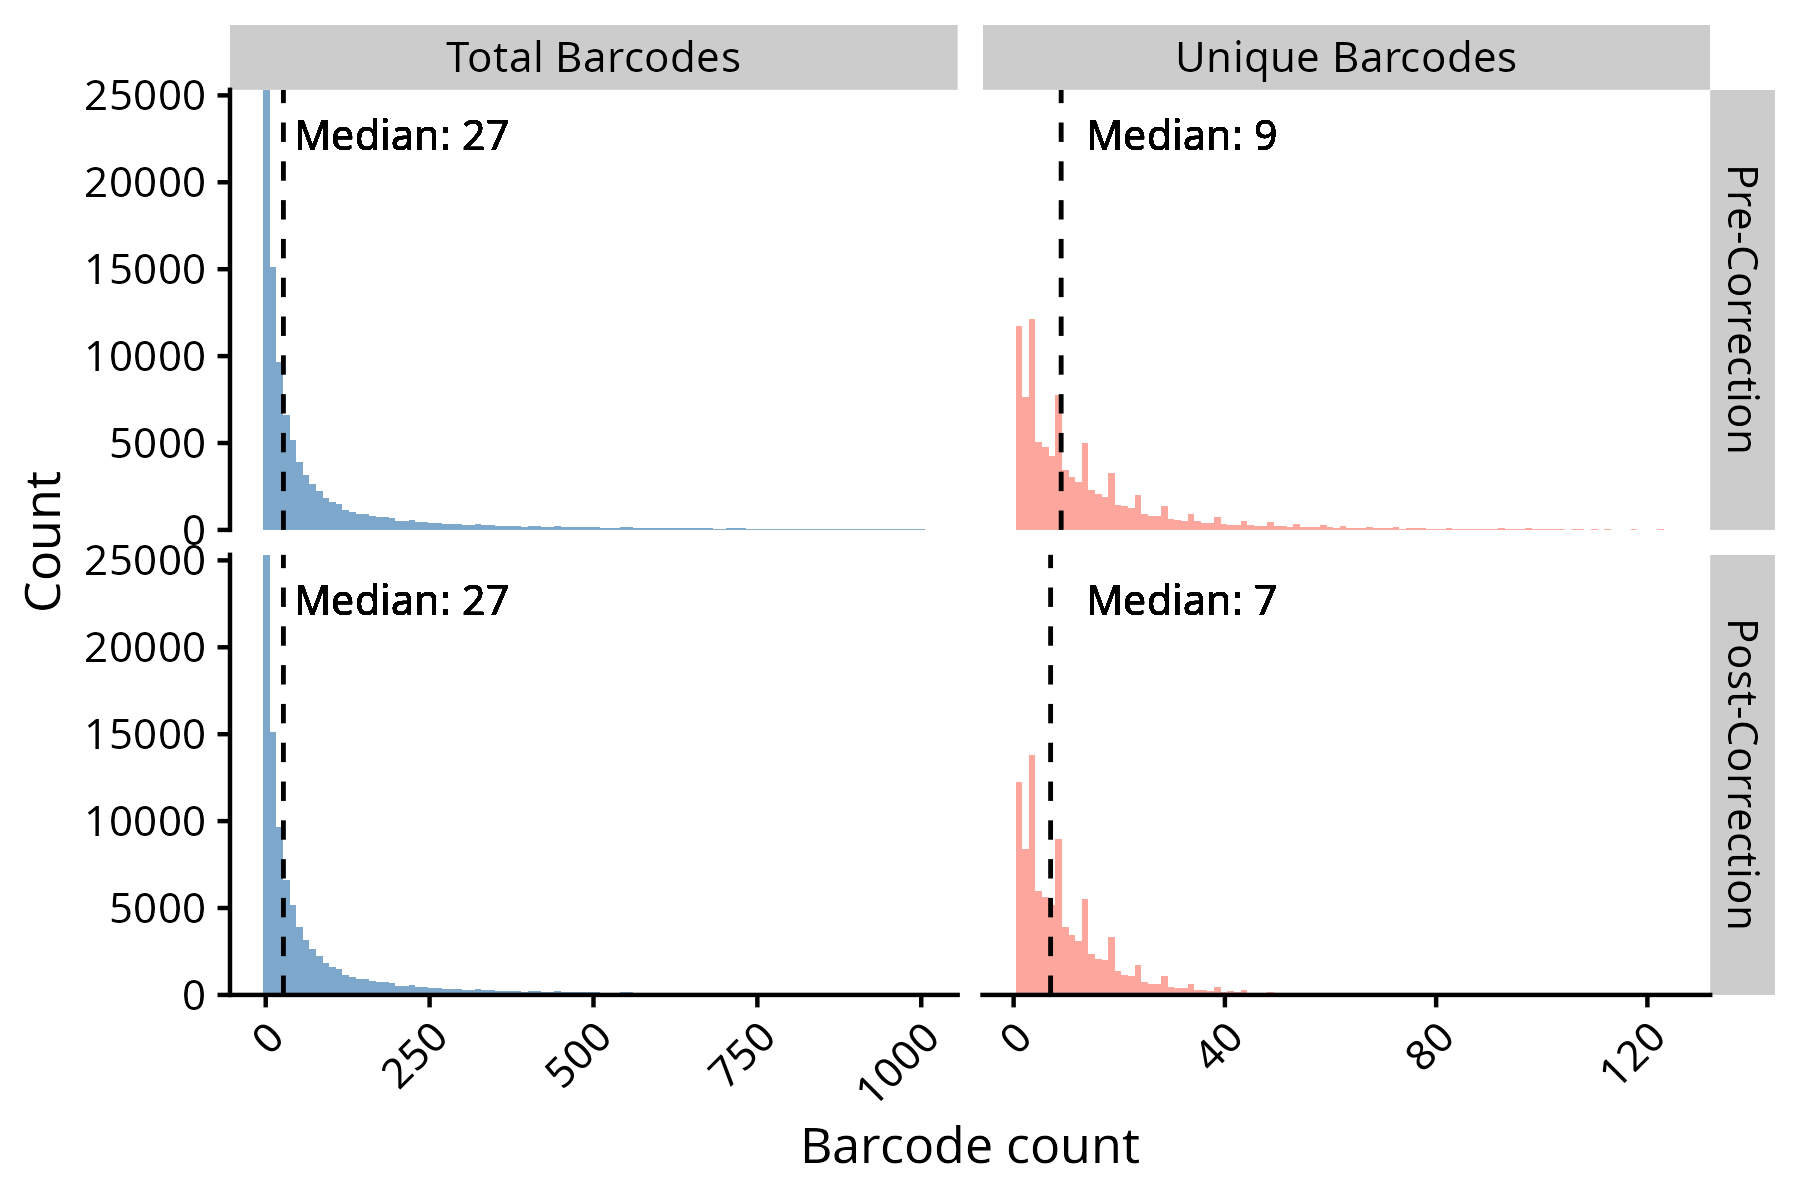

Continue with the next steps:

Similar to the barcode correction, we now want to obtain a consensus sequence of each cDNA sequence for each unique barcode instance. 

After that we will align that consensus sequence to the reference cDNA sequence to obtain the final annotation.